## Imports

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import warnings
warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=FutureWarning)

from randomness import *
from df_metrics import *
from simulation_exact import *
from utils import *
from data_analysis import *
from main import *
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
from joblib import Parallel, delayed
from itertools import product

#seed = 42
#np.random.seed(seed)
#rng = np.random.default_rng(seed)

## Learning parameters 

In [11]:
use_loss = 'hinge' #'log' or 'hinge' or 'squared_hinge' 
sigma_loss = 1.0 
c = 1.0 # choose c without scaling 
show_plots = False # set to True to see plots of the binary search
is_throw = True # set to True to throw out points outside margin --> only when loss is lipschitz. 
#TODO: add is throw to outside_inside function 
k = None # if none will be set based on data max norm
k_coef = 1.0 # coefficient to multiply k with
fit_intercept = True # whether to fit intercept in SVM model
ds = [2, 4, 8, 16, 32, 64] # dimensions to run experiments on
T = 200  # number of trials

## Generate V's

In [8]:
def generate_v_data(n_neg, n_pos, rng = None):
    return np.ones(n_neg+n_pos)

In [9]:
def generate_v_data_2(n_neg, n_pos, rng = None):
    return np.ones(n_neg+n_pos)

## Run for Beta distrbuted data 

In [23]:
def generate_beta_data(n_neg, n_pos, alpha_neg, beta_neg, 
                       alpha_pos, beta_pos, rng, d=1):
    # Sample negative points
    neg_samples = rng.beta(alpha_neg, beta_neg, size=(n_neg, d))
    
    # Sample positive points
    pos_samples = rng.beta(alpha_pos, beta_pos, size=(n_pos, d))
    
    # Combine and return
    X = np.vstack([neg_samples, pos_samples])

    y = np.concatenate([-1 * np.ones(n_neg), np.ones(n_pos)])

    v = generate_v_data(n_neg, n_pos)

    return X, y, v

In [9]:
# 1. choose n for training and validation  
n_pos = 50 # number of data points in a sample with label 1
n_neg = 50 # number of data points in a sample with label -1
n_val_pos = 200
n_val_neg = 200

# 2. distrbution parameters 
alpha_neg = 5
beta_neg = 2
alpha_pos = 2
beta_pos = 5
betas = np.linspace(10, 2, 21) # different sigmas to run the experiments on


In [ ]:
# 3. run exact sisigmalation
# returns df with cols "agent" | "true_v" | "critical_v" | "allocation" | "welfare" | "utility"
# utility = welfare - payment
# welfare = allocation * true_v
# critical_v = payment 

def compute_metrics_beta(t):
    dfs = []
    for d in ds:
        for beta in betas:
            seed = hash((t, d, beta)) % (2**32)
            rng = np.random.default_rng(seed)
            #beta_neg = alpha_pos = beta 
            x, y, v =  generate_beta_data(n_neg, n_pos, alpha_neg, beta, beta, beta_pos, rng, d)
            x_val, y_val, _ = generate_beta_data(n_val_neg, n_val_pos, alpha_neg, beta, beta, beta_pos, rng, d)
            
            df_exact, svm_model = run_exact(x, y, v, c, use_loss, sigma_loss=sigma_loss, plot=show_plots, 
                                    is_throw=is_throw, k=k, k_coef=k_coef, fit_intercept=fit_intercept)
            df_exact['t'] = t
            df_exact['d'] = d
            df_exact['beta'] = beta
            df_exact['valid_acc'] = svm_model.score(x_val,y_val)
            df_exact['label'] = y[df_exact['agent'].astype(int)]
            dfs.append(df_exact)

    return pd.concat(dfs, ignore_index=True)

# Run for gaussians

In [4]:
def generate_gaus_data(n_pos, n_neg, mu_pos, mu_neg, sigma_pos, sigma_neg, rng, d=1):
    X_neg = rng.normal(loc=mu_neg, scale=sigma_neg, size=(n_neg, d)) # label -1 
    X_pos = rng.normal(loc=mu_pos, scale=sigma_pos, size=(n_pos, d)) # label 1 
    X = np.vstack([X_neg, X_pos])
    y = np.concatenate([-1 * np.ones(n_neg),np.ones(n_pos)])

    v = generate_v_data(n_neg, n_pos)
    return X, y, v

## Run for two gaussians: fixed sigmas, changing mus : gaus_1

In [5]:
# choose parameters 
n_pos = 50 # number of data points in a sample with label 1
n_neg = 50 # number of data points in a sample with label -1
n_val_pos = 200
n_val_neg = 200
sigma_pos = 1.0
sigma_neg = 1.0
mus = np.linspace(1, 0, 21) # different sigmas to run the experiments on

In [16]:
# run exact sisigmalation
# returns df with cols "agent" | "true_v" | "critical_v" | "allocation" | "welfare" | "utility"
# utility = welfare - payment
# welfare = allocation * true_v
# critical_v = payment 

def compute_metrics_gaus_1(t):
    dfs = []
    for d in ds:
        for mu_scalar in mus:
            mu = np.concatenate(([mu_scalar], np.zeros(d - 1)))
            seed = hash((t, d, mu_scalar)) % (2**32)
            rng = np.random.default_rng(seed)
            x, y, v = generate_gaus_data(n_pos, n_neg, mu, -mu, sigma_pos, sigma_neg, rng, d)
            x_val, y_val, _ = generate_gaus_data(n_val_pos, n_val_neg, mu, -mu, sigma_pos, sigma_neg, rng, d)
            
            df_exact, svm_model = run_exact(x, y, v, c, use_loss, sigma_loss=sigma_loss, plot=show_plots, 
                                    is_throw=is_throw, k=k, k_coef=k_coef, fit_intercept=fit_intercept)
            df_exact['t'] = t
            df_exact['d'] = d
            df_exact['mu'] = mu_scalar
            df_exact['valid_acc'] = svm_model.score(x_val,y_val)
            df_exact['label'] = y[df_exact['agent'].astype(int)]
            dfs.append(df_exact)

    return pd.concat(dfs, ignore_index=True)

## Run for two gaussians: fixed mus, changing sigmas : gaus_2

In [14]:
# choose parameters 
n_pos = 50 # number of data points in a sample with label 1
n_neg = 50 # number of data points in a sample with label -1
n_val_pos = 200
n_val_neg = 200

mu_pos = 0.5 # class 1 mean
mu_neg = -0.5 # class -1 mean
sigma_pos = 1.0
sigma_neg = 1.0
sigmas = np.linspace(1.5, 0.1, 11) # different sigmas to run the experiments on

In [ ]:
# run exact sisigmalation
# returns df with cols "agent" | "true_v" | "critical_v" | "allocation" | "welfare" | "utility"
# utility = welfare - payment
# welfare = allocation * true_v
# critical_v = payment 

def compute_metrics_gaus_2(t):
    dfs = []
    for d in ds:
        for sigma in sigmas:
            seed = hash((t, d, sigma)) % (2**32)
            rng = np.random.default_rng(seed)
            x, y, v =  generate_gaus_data(n_pos, n_neg, mu_pos, mu_neg, sigma_pos, sigma_neg, rng, d)
            x_val, y_val, _ =  generate_gaus_data(n_val_pos, n_val_neg, mu_pos, mu_neg, sigma_pos, sigma_neg, rng, d)
            
            df_exact, svm_model = run_exact(x, y, v, c, use_loss, sigma_loss=sigma_loss, plot=show_plots, 
                                    is_throw=is_throw, k=k, k_coef=k_coef, fit_intercept=fit_intercept)
            df_exact['t'] = t
            df_exact['d'] = d
            df_exact['sigma'] = sigma
            df_exact['valid_acc'] = svm_model.score(x_val,y_val)
            df_exact['label'] = y[df_exact['agent'].astype(int)]
            dfs.append(df_exact)

    return pd.concat(dfs, ignore_index=True)

# Run experiments

In [17]:
mega_df = pd.concat( 
    Parallel(n_jobs=-1, backend="loky")(
        delayed(compute_metrics_gaus_1)(t) for t in range(T)
        ), 
        ignore_index=True
)

/home/sadi.bana/bana_project/accuracy_limited_resource/main.py:328: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_exact = pd.concat([df_exact, pd.DataFrame([{
/home/sadi.bana/bana_project/accuracy_limited_resource/main.py:328: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_exact = pd.concat([df_exact, pd.DataFrame([{
/home/sadi.bana/bana_project/accuracy_limited_resource/main.py:328: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a futu

## Analysis

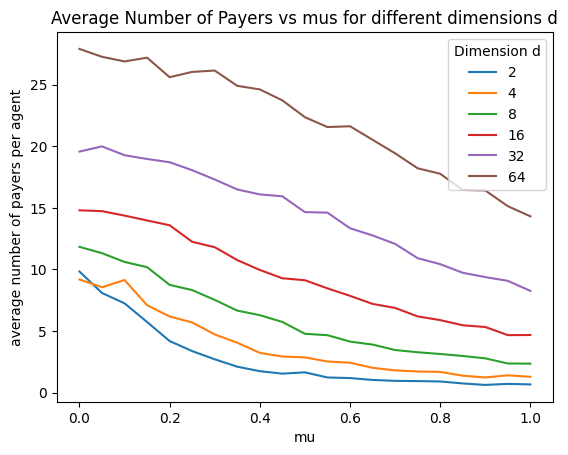

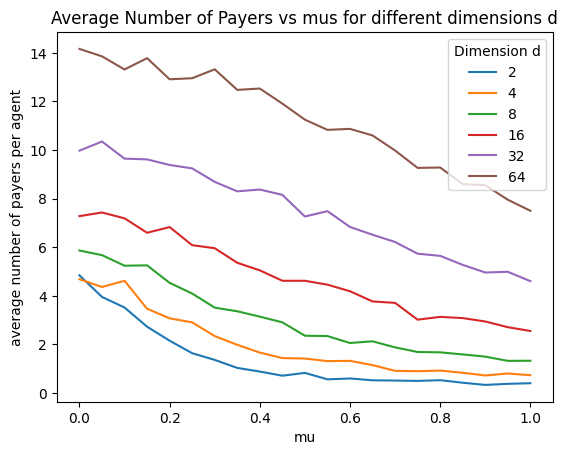

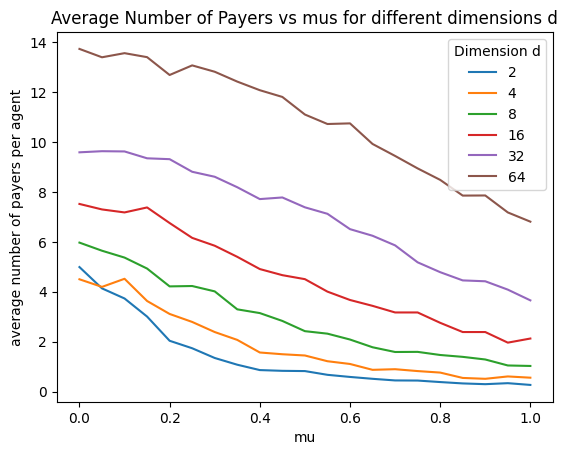

In [18]:
var = 'mu'
plot_mean_num_payers(mega_df, var, labels = [1, -1])
plot_mean_num_payers(mega_df, var, labels = [-1])
plot_mean_num_payers(mega_df, var, labels = [1])

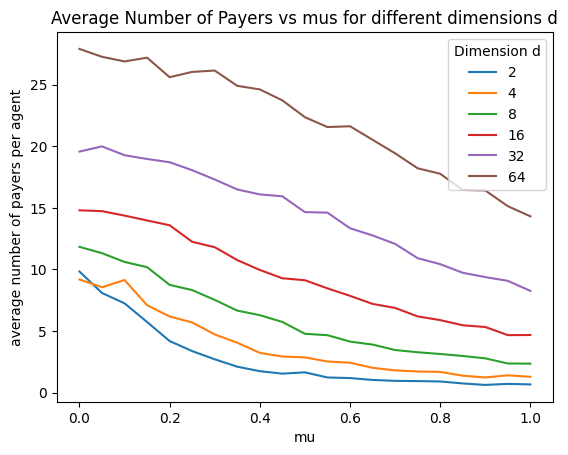

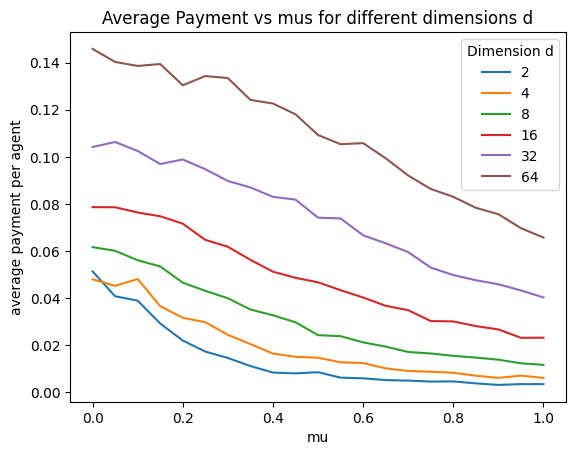

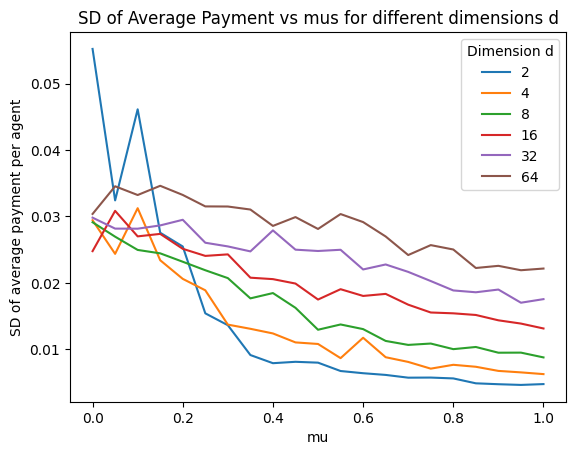

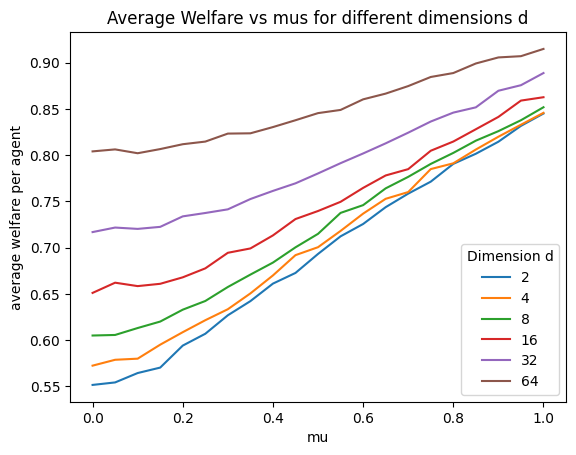

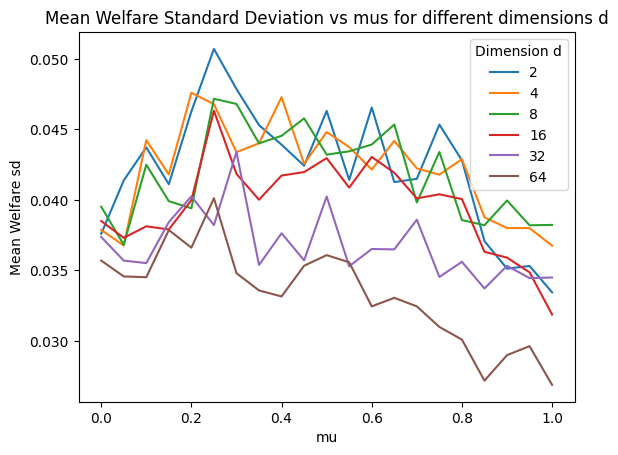

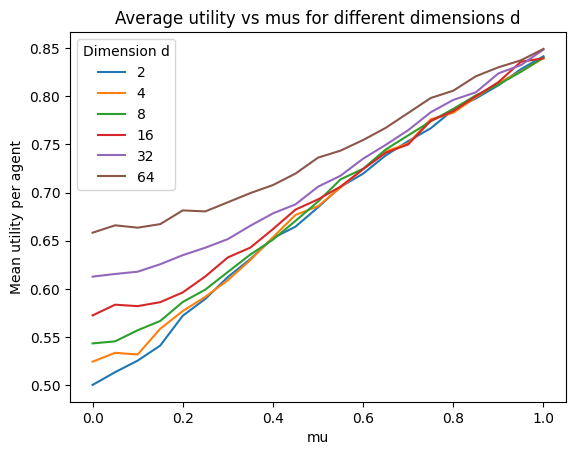

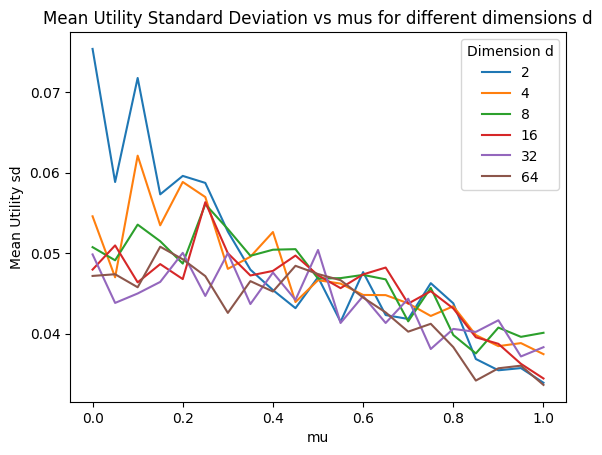

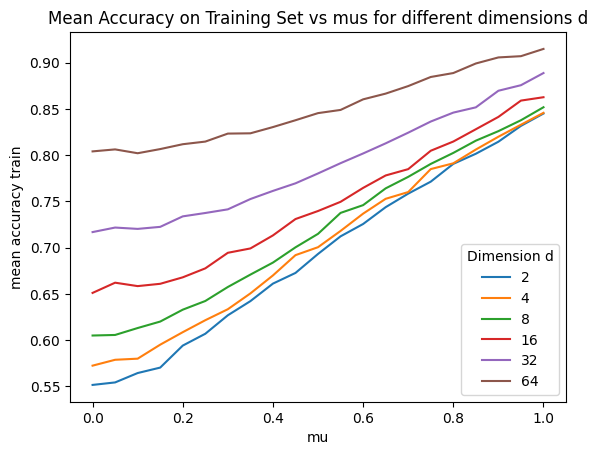

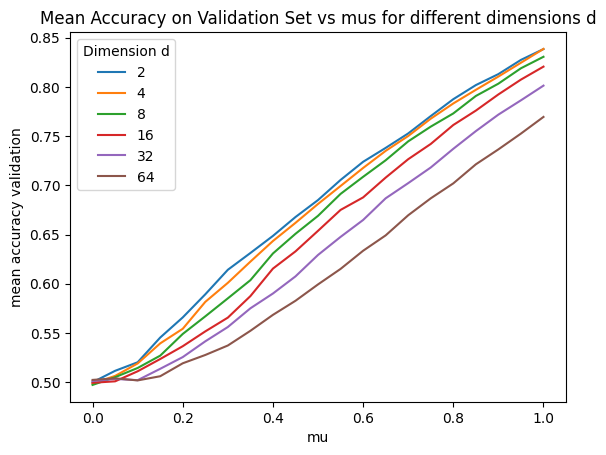

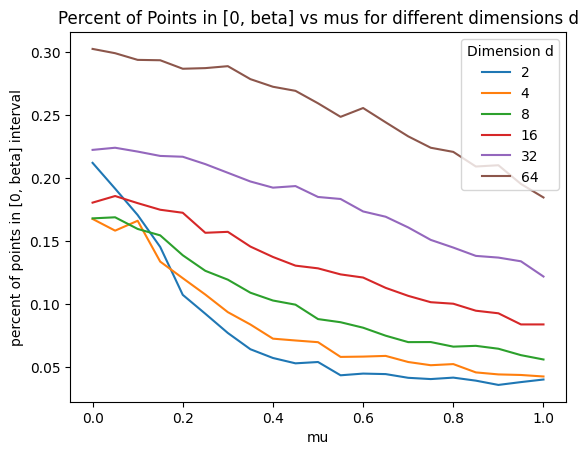

In [59]:
var = 'mu'
plot_mean_num_payers(mega_df, var, labels = [1, -1])
plot_mean_payment(mega_df, var, labels = [1, -1])
plot_mean_payment_sd(mega_df, var, labels = [1, -1])

#welfare metrics plots
plot_mean_welfare(mega_df, var, labels = [1, -1])
plot_mean_welfare_sd(mega_df, var, labels = [1, -1])

# utility metrics plots
plot_mean_utility(mega_df, var, labels = [1, -1])
plot_mean_utility_sd(mega_df, var, labels = [1, -1])


# accuracy metrics plots
plot_mean_accuracy_train(mega_df, var, labels = [1, -1])

plot_mean_accuracy_validation(mega_df, var, labels = [1, -1])

# percent of points in [0, beta] interval 
plot_percent_relevant(mega_df, var, labels = [1, -1])